In [ ]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import streamlit as st
import holidays

In [3]:
from pathlib import Path

# Ruta base desde la carpeta notebooks
base_dir = Path.cwd()
if base_dir.name != "notebooks":
    base_dir = base_dir / "notebooks"

# Cargar datos desde data/raw/entrenamiento
ventas_path = base_dir.parent / "data" / "raw" / "entrenamiento" / "ventas.csv"
competencias_path = base_dir.parent / "data" / "raw" / "entrenamiento" / "competencia.csv"

df_ventas = pd.read_csv(ventas_path)
df_competencia = pd.read_csv(competencias_path)

print("Ventas cargadas:", df_ventas.shape)
print("Competencias cargadas:", df_competencia.shape)
print(df_ventas.head())
print(df_competencia.head())


Ventas cargadas: (3552, 10)
Competencias cargadas: (3552, 5)
        fecha producto_id                            nombre categoria  \
0  2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1  2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
2  2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
3  2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   
4  2021-10-25    PROD_005                Nike Dri-FIT Miler   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1  Zapatillas Running          135         True                 10   
2  Zapatillas Running           85        False                  2   
3  Zapatillas Running           75        False                  2   
4        Ropa Running           35        False                  2   

   precio_venta  ingresos  
0        118.36    710.16  
1        136.82   1368.

In [4]:
df_ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [5]:
df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [9]:
df_ventas.columns

Index(['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria',
       'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta',
       'ingresos'],
      dtype='str')

In [10]:
df_competencia.columns

Index(['fecha', 'producto_id', 'Amazon', 'Decathlon', 'Deporvillage'], dtype='str')

In [11]:
# Informe de calidad de datos para df_ventas
from pathlib import Path

base_dir = Path.cwd()
if base_dir.name != "notebooks":
    base_dir = base_dir / "notebooks"

ventas_path = base_dir.parent / "data" / "raw" / "entrenamiento" / "ventas.csv"
df_ventas = pd.read_csv(ventas_path)

print("Forma del DataFrame:", df_ventas.shape)
print("\nTipos de variables:")
print(df_ventas.dtypes)

print("\nNulos por columna:")
print(df_ventas.isnull().sum())

print("\nFilas duplicadas:", df_ventas.duplicated().sum())

print("\nEstadísticos descriptivos:")
print(df_ventas.describe(include="all").T)

quality_report = pd.DataFrame({
    "tipo": df_ventas.dtypes.astype(str),
    "nulos": df_ventas.isnull().sum(),
    "nulos_pct": (df_ventas.isnull().mean() * 100).round(2),
    "valores_unicos": df_ventas.nunique(dropna=False)
})

print("\nInforme de calidad por columna:")
print(quality_report)

summary = pd.DataFrame({
    "métrica": [
        "filas",
        "columnas",
        "columnas_con_nulos",
        "total_nulos",
        "filas_duplicadas"
    ],
    "valor": [
        df_ventas.shape[0],
        df_ventas.shape[1],
        int((df_ventas.isnull().sum() > 0).sum()),
        int(df_ventas.isnull().sum().sum()),
        int(df_ventas.duplicated().sum())
    ]
})

print("\nResumen final de calidad de datos:")
print(summary)


Forma del DataFrame: (3552, 10)

Tipos de variables:
fecha                    str
producto_id              str
nombre                   str
categoria                str
subcategoria             str
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

Nulos por columna:
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

Filas duplicadas: 0

Estadísticos descriptivos:
                    count unique                       top  freq        mean  \
fecha                3552    148                2021-10-25    24         NaN   
producto_id          3552     24                  PROD_001   148         NaN   
nombre               3552     24  Nike Air Zoom Pegasus 40   148         NaN   
categoria  

In [ ]:
df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"], errors="coerce")
df_ventas = df_ventas.sort_values("fecha").reset_index(drop=True)

df_ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15
2,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
3,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
4,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84


In [17]:
# Informe de calidad de datos para df_competencia
print("Forma del DataFrame de competencia:", df_competencia.shape)
print("\nTipos de variables:")
print(df_competencia.dtypes)

print("\nNulos por columna:")
print(df_competencia.isnull().sum())

print("\nFilas duplicadas:", df_competencia.duplicated().sum())

print("\nEstadísticos descriptivos:")
print(df_competencia.describe(include="all").T)

quality_report_competencia = pd.DataFrame({
    "tipo": df_competencia.dtypes.astype(str),
    "nulos": df_competencia.isnull().sum(),
    "nulos_pct": (df_competencia.isnull().mean() * 100).round(2),
    "valores_unicos": df_competencia.nunique(dropna=False)
})

print("\nInforme de calidad por columna:")
print(quality_report_competencia)

summary_competencia = pd.DataFrame({
    "métrica": [
        "filas",
        "columnas",
        "columnas_con_nulos",
        "total_nulos",
        "filas_duplicadas"
    ],
    "valor": [
        df_competencia.shape[0],
        df_competencia.shape[1],
        int((df_competencia.isnull().sum() > 0).sum()),
        int(df_competencia.isnull().sum().sum()),
        int(df_competencia.duplicated().sum())
    ]
})

print("\nResumen final de calidad de datos para df_competencia:")
print(summary_competencia)


Forma del DataFrame de competencia: (3552, 5)

Tipos de variables:
fecha               str
producto_id         str
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

Nulos por columna:
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

Filas duplicadas: 0

Estadísticos descriptivos:
               count unique         top freq        mean         std    min  \
fecha           3552    148  2021-10-25   24         NaN         NaN    NaN   
producto_id     3552     24    PROD_001  148         NaN         NaN    NaN   
Amazon        3552.0    NaN         NaN  NaN  118.623407  156.095628  16.85   
Decathlon     3552.0    NaN         NaN  NaN  111.412182  148.508132  15.45   
Deporvillage  3552.0    NaN         NaN  NaN  118.894628  160.216448  16.77   

                  25%     50%       75%       max  
fecha             NaN     NaN       NaN       NaN  
producto_id       NaN     NaN       NaN       Na

In [18]:
df_competencia["fecha"] = pd.to_datetime(df_competencia["fecha"], errors="coerce")
df_competencia = df_competencia.sort_values("fecha").reset_index(drop=True)

df_competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_024,46.96,44.19,50.44
2,2021-10-25,PROD_023,34.30,33.16,34.42
3,2021-10-25,PROD_022,19.38,17.45,19.82
4,2021-10-25,PROD_021,127.72,106.44,118.27


In [21]:
df_ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[us]
 1   producto_id        3552 non-null   str           
 2   nombre             3552 non-null   str           
 3   categoria          3552 non-null   str           
 4   subcategoria       3552 non-null   str           
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[us](1), float64(2), int64(2), str(4)
memory usage: 434.9 KB


In [22]:
df_competencia.info()

<class 'pandas.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[us]
 1   producto_id   3552 non-null   str           
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[us](1), float64(3), str(1)
memory usage: 167.1 KB


In [23]:
# Integración de ventas y competencia en un único dataframe
# Claves: fecha y producto_id

df = (
    df_ventas
    .merge(
        df_competencia,
        on=["fecha", "producto_id"],
        how="inner",
        validate="one_to_one"
    )
)

print("Forma del DataFrame integrado:", df.shape)
print(df.head())
print("\nColumnas del dataframe integrado:")
print(df.columns.tolist())


Forma del DataFrame integrado: (3552, 13)
       fecha producto_id                            nombre categoria  \
0 2021-10-25    PROD_001          Nike Air Zoom Pegasus 40   Running   
1 2021-10-25    PROD_012        Domyos Kit Mancuernas 20kg   Fitness   
2 2021-10-25    PROD_002              Adidas Ultraboost 23   Running   
3 2021-10-25    PROD_003               Asics Gel Nimbus 25   Running   
4 2021-10-25    PROD_004  New Balance Fresh Foam X 1080v12   Running   

         subcategoria  precio_base  es_estrella  unidades_vendidas  \
0  Zapatillas Running          115         True                  6   
1          Pesas Casa           55        False                  3   
2  Zapatillas Running          135         True                 10   
3  Zapatillas Running           85        False                  2   
4  Zapatillas Running           75        False                  2   

   precio_venta  ingresos  Amazon  Decathlon  Deporvillage  
0        118.36    710.16   82.96     111.8

In [24]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_012,Domyos Kit Mancuernas 20kg,Fitness,Pesas Casa,55,False,3,55.05,165.15,52.50,50.60,56.64
2,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
3,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
4,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45


# Análisis exploratorio completo de df

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

# Cargar datos si el dataframe integrado no existe
if "df" not in globals():
    base_dir = Path.cwd()
    if base_dir.name != "notebooks":
        base_dir = base_dir / "notebooks"

    ventas_path = base_dir.parent / "data" / "raw" / "entrenamiento" / "ventas.csv"
    competencias_path = base_dir.parent / "data" / "raw" / "entrenamiento" / "competencia.csv"

    df_ventas = pd.read_csv(ventas_path)
    df_competencia = pd.read_csv(competencias_path)

    df_ventas["fecha"] = pd.to_datetime(df_ventas["fecha"], errors="coerce")
    df_competencia["fecha"] = pd.to_datetime(df_competencia["fecha"], errors="coerce")

    df = (
        df_ventas.merge(
            df_competencia,
            on=["fecha", "producto_id"],
            how="inner",
            validate="one_to_one"
        )
    )

# Asegurar tipos de fecha y orden
if "fecha" in df.columns:
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df = df.sort_values("fecha").reset_index(drop=True)

# Variables temporales y de negocio
if "fecha" in df.columns:
    df["anio"] = df["fecha"].dt.year
    df["mes"] = df["fecha"].dt.month
    df["dia_semana"] = df["fecha"].dt.day_name()
    df["dia_semana_num"] = df["fecha"].dt.dayofweek

# Orden de días de la semana para plots
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["dia_semana_ordenado"] = pd.Categorical(df["dia_semana"], categories=orden_dias, ordered=True)

# Conversión de precios a numérico
for col in ["precio_base", "precio_venta", "Amazon"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Fechas de Black Friday por año
black_friday_dates = {}
for year in sorted(df["anio"].dropna().unique()):
    thanksgiving = pd.Timestamp(year, 11, 1) + pd.offsets.WeekOfMonth(week=3, weekday=3)
    black_friday_dates[year] = thanksgiving + pd.Timedelta(days=1)

df["es_black_friday"] = df["fecha"].isin(list(black_friday_dates.values()))

print("Resumen del dataframe preparado:")
print(df[["fecha", "anio", "mes", "dia_semana", "unidades_vendidas", "precio_venta", "Amazon"]].head())
print("\nBlack Fridays detectados:")
for year, date_value in black_friday_dates.items():
    print(year, date_value.strftime("%Y-%m-%d"))


Resumen del dataframe preparado:
       fecha  anio  mes dia_semana  unidades_vendidas  precio_venta  Amazon
0 2021-10-25  2021   10     Monday                  6        118.36   82.96
1 2021-10-25  2021   10     Monday                  3         55.05   52.50
2 2021-10-25  2021   10     Monday                 10        136.82  112.56
3 2021-10-25  2021   10     Monday                  2         84.93   79.79
4 2021-10-25  2021   10     Monday                  2         75.42   72.60

Black Fridays detectados:
2021 2021-11-26
2022 2022-11-25
2023 2023-11-24
2024 2024-11-29


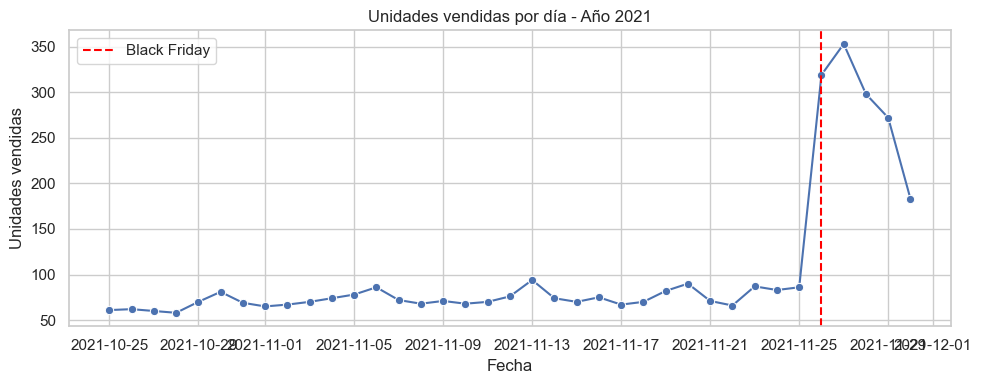

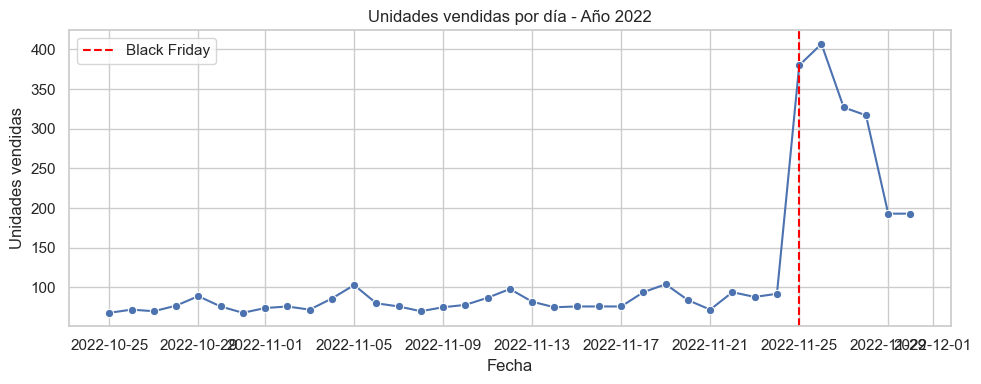

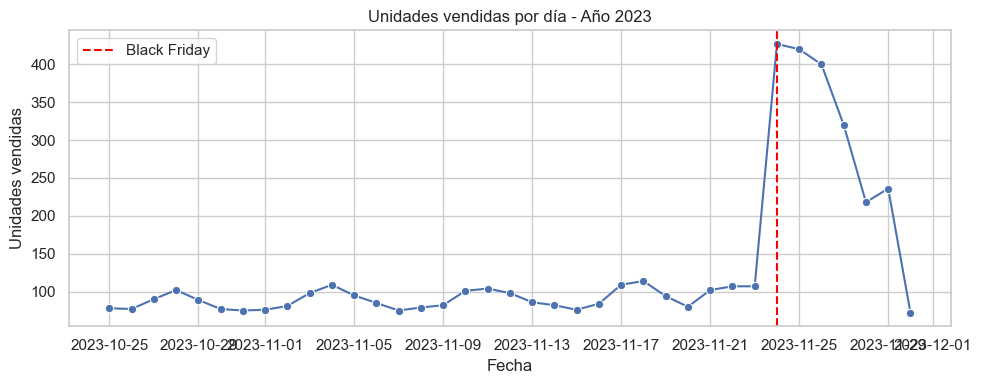

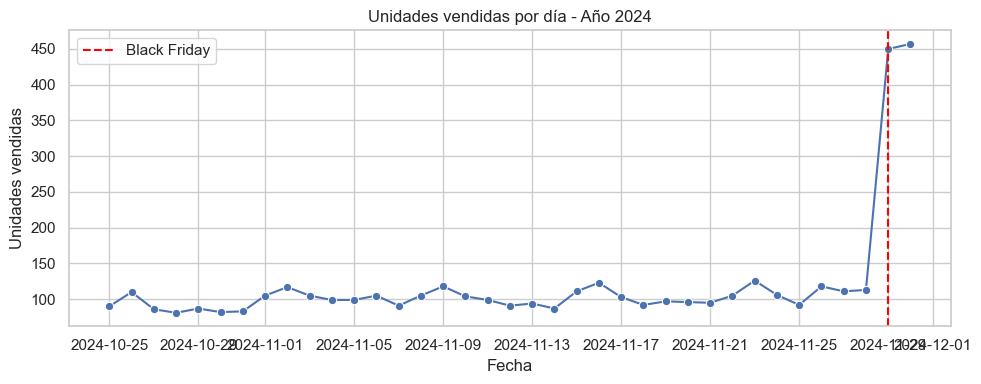

In [4]:
# 1) Series temporales por año con suma de unidades vendidas y marca de Black Friday
if "fecha" in df.columns and "unidades_vendidas" in df.columns:
    yearly_sales = df.groupby(["anio", "fecha"])["unidades_vendidas"].sum().reset_index()
    yearly_sales = yearly_sales.sort_values(["anio", "fecha"])
    
    for year in sorted(yearly_sales["anio"].dropna().unique()):
        subset = yearly_sales[yearly_sales["anio"] == year].copy()
        plt.figure(figsize=(10, 4))
        ax = sns.lineplot(data=subset, x="fecha", y="unidades_vendidas", marker="o", color="#4C72B0")
        if year in black_friday_dates:
            bf_date = black_friday_dates[year]
            ax.axvline(bf_date, color="red", linestyle="--", linewidth=1.5, label="Black Friday")
        ax.set_title(f"Unidades vendidas por día - Año {year}")
        ax.set_xlabel("Fecha")
        ax.set_ylabel("Unidades vendidas")
        ax.legend()
        plt.tight_layout()
        plt.show()


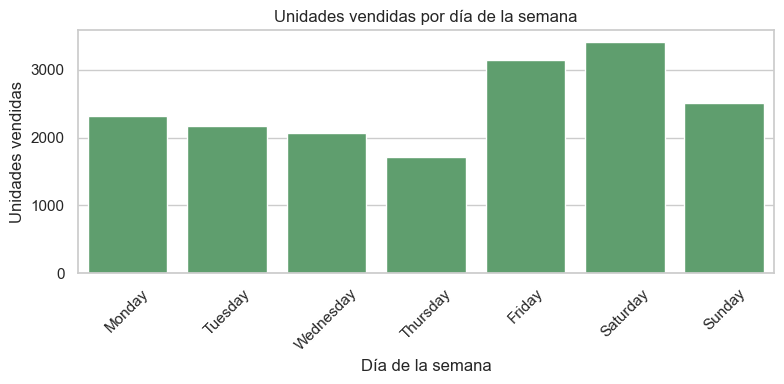

In [5]:
# 2) Suma de unidades vendidas por día de la semana
if "dia_semana_ordenado" in df.columns and "unidades_vendidas" in df.columns:
    ventas_dia = (
        df.groupby("dia_semana_ordenado")["unidades_vendidas"]
        .sum()
        .reset_index(name="unidades_vendidas")
    )
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=ventas_dia, x="dia_semana_ordenado", y="unidades_vendidas", color="#55A868")
    ax.set_title("Unidades vendidas por día de la semana")
    ax.set_xlabel("Día de la semana")
    ax.set_ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


C:\Users\diego\AppData\Local\Temp\ipykernel_25776\1136911579.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ventas_categoria, x="categoria", y="unidades_vendidas", palette="Reds")


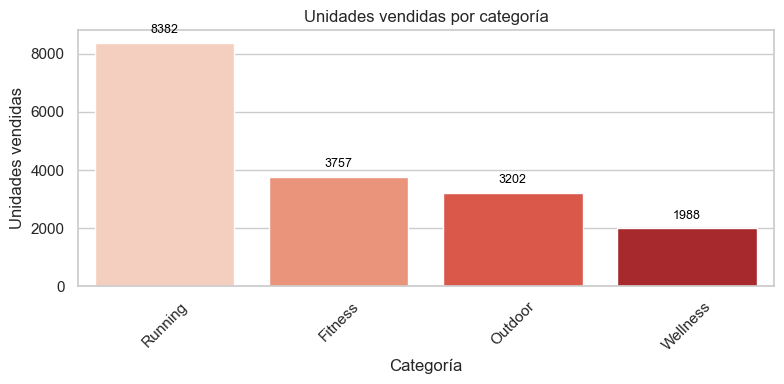

In [11]:
# 3) Suma de unidades vendidas por categoría
if "categoria" in df.columns and "unidades_vendidas" in df.columns:
    ventas_categoria = (
        df.groupby("categoria")["unidades_vendidas"]
        .sum()
        .reset_index(name="unidades_vendidas")
        .sort_values("unidades_vendidas", ascending=False)
    )
    plt.figure(figsize=(8, 4))
    ax = sns.barplot(data=ventas_categoria, x="categoria", y="unidades_vendidas", palette="Reds")
    for p in ax.patches:
        ax.annotate(
            format(p.get_height(), '.0f'),
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=9,
            color='black',
            xytext=(0, 5),
            textcoords='offset points'
        )
    ax.set_title("Unidades vendidas por categoría")
    ax.set_xlabel("Categoría")
    ax.set_ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


C:\Users\diego\AppData\Local\Temp\ipykernel_25776\2059352362.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=ventas_subcategoria, x="subcategoria", y="unidades_vendidas", palette="mako")


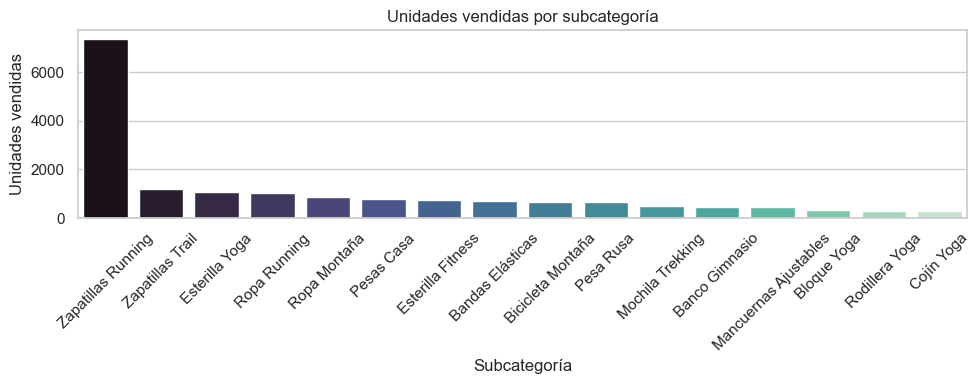

In [7]:
# 4) Suma de unidades vendidas por subcategoría
if "subcategoria" in df.columns and "unidades_vendidas" in df.columns:
    ventas_subcategoria = (
        df.groupby("subcategoria")["unidades_vendidas"]
        .sum()
        .reset_index(name="unidades_vendidas")
        .sort_values("unidades_vendidas", ascending=False)
    )
    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=ventas_subcategoria, x="subcategoria", y="unidades_vendidas", palette="mako")
    ax.set_title("Unidades vendidas por subcategoría")
    ax.set_xlabel("Subcategoría")
    ax.set_ylabel("Unidades vendidas")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


C:\Users\diego\AppData\Local\Temp\ipykernel_25776\494775457.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_productos, x="unidades_vendidas", y="nombre", palette="rocket")


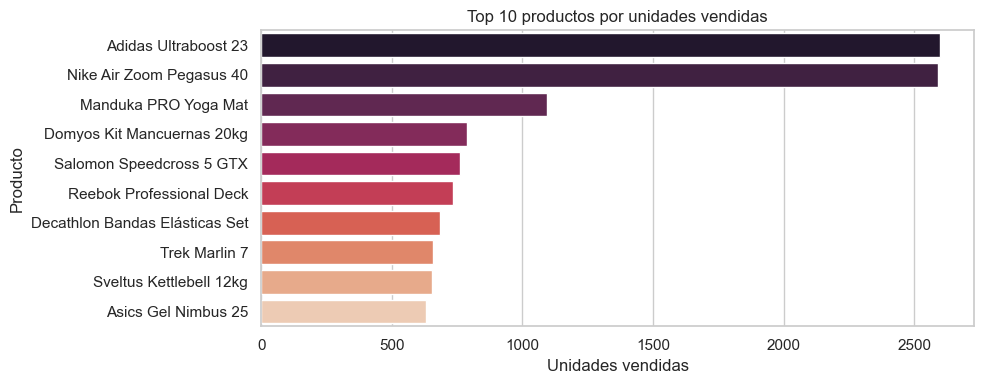

In [8]:
# 5) Top productos por unidades vendidas
if "nombre" in df.columns and "unidades_vendidas" in df.columns:
    top_productos = (
        df.groupby("nombre")["unidades_vendidas"]
        .sum()
        .reset_index(name="unidades_vendidas")
        .sort_values("unidades_vendidas", ascending=False)
        .head(10)
    )
    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=top_productos, x="unidades_vendidas", y="nombre", palette="rocket")
    ax.set_title("Top 10 productos por unidades vendidas")
    ax.set_xlabel("Unidades vendidas")
    ax.set_ylabel("Producto")
    plt.tight_layout()
    plt.show()


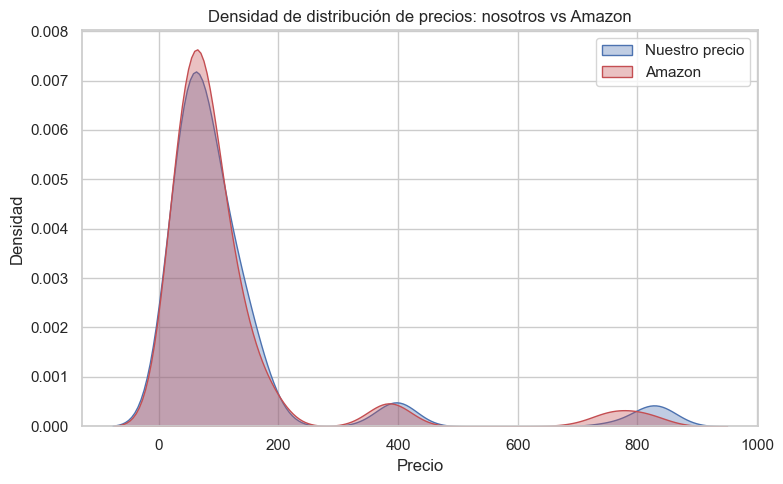

In [9]:
# 6) Densidad de distribución de precios: propios vs competencia Amazon
if {"precio_venta", "Amazon"}.issubset(df.columns):
    precio_plot = df[["precio_venta", "Amazon"]].dropna()
    precio_plot = precio_plot.rename(columns={"precio_venta": "Nuestro precio", "Amazon": "Amazon"})
    
    plt.figure(figsize=(8, 5))
    ax = sns.kdeplot(data=precio_plot, x="Nuestro precio", fill=True, alpha=0.35, color="#4C72B0", label="Nuestro precio")
    sns.kdeplot(data=precio_plot, x="Amazon", fill=True, alpha=0.35, color="#C44E52", label="Amazon")
    ax.set_title("Densidad de distribución de precios: nosotros vs Amazon")
    ax.set_xlabel("Precio")
    ax.set_ylabel("Densidad")
    ax.legend()
    plt.tight_layout()
    plt.show()


# Creación de variables y preparación de datos

In [18]:
# Variables temporales y de calendario para el modelo
if "fecha" in df.columns:
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df = df.sort_values("fecha").reset_index(drop=True)

    df["anio"] = df["fecha"].dt.year
    df["mes"] = df["fecha"].dt.month
    df["dia_mes"] = df["fecha"].dt.day
    df["dia_semana"] = df["fecha"].dt.day_name()
    df["dia_semana_num"] = df["fecha"].dt.dayofweek
    df["es_fin_de_semana"] = df["dia_semana_num"].isin([5, 6])
    df["es_inicio_mes"] = df["fecha"].dt.is_month_start
    df["es_fin_mes"] = df["fecha"].dt.is_month_end
    df["es_inicio_trimestre"] = df["fecha"].dt.is_quarter_start
    df["es_fin_trimestre"] = df["fecha"].dt.is_quarter_end
    df["semana_del_anio"] = df["fecha"].dt.isocalendar().week.astype(int)
    df["trimestre"] = df["fecha"].dt.quarter
    df["cuatrimestre"] = ((df["mes"] - 1) // 4) + 1
    df["mes_nombre"] = df["fecha"].dt.month_name()
    df["es_primera_quincena"] = df["dia_mes"].le(15)
    df["es_segunda_quincena"] = df["dia_mes"].gt(15)

    years = sorted(df["anio"].dropna().astype(int).unique())
    holiday_calendar = holidays.country_holidays("ES", years=years)
    df["es_festivo"] = df["fecha"].isin(list(holiday_calendar.keys()))
    df["nombre_festivo"] = df["fecha"].apply(lambda x: holiday_calendar.get(x, "") if pd.notna(x) else "")

    # Black Friday y Cyber Monday (aproximados a partir del jueves de Acción de Gracias)
    black_friday_dates = [
        pd.Timestamp(year, 11, 1) + pd.offsets.WeekOfMonth(week=3, weekday=3) + pd.Timedelta(days=1)
        for year in years
    ]
    cyber_monday_dates = [
        pd.Timestamp(year, 11, 1) + pd.offsets.WeekOfMonth(week=3, weekday=3) + pd.Timedelta(days=8)
        for year in years
    ]
    df["es_black_friday"] = df["fecha"].isin(black_friday_dates)
    df["es_ciber_monday"] = df["fecha"].isin(cyber_monday_dates)

    # Variables adicionales de calendario para captar estacionalidad
    df["es_navidad"] = df["mes"].eq(12) & df["dia_mes"].isin([24, 25, 26, 31])
    df["es_reyes"] = df["mes"].eq(1) & df["dia_mes"].eq(6)
    df["es_san_juan"] = df["mes"].eq(6) & df["dia_mes"].eq(24)
    df["es_ha_duplicado"] = df.duplicated(subset=["fecha", "producto_id"], keep=False)

    print("Variables temporales creadas correctamente.")
    print(df[["fecha", "anio", "mes", "dia_mes", "dia_semana", "es_fin_de_semana", "es_festivo", "es_black_friday", "es_ciber_monday", "es_navidad", "es_reyes"]].head())


Variables temporales creadas correctamente.
       fecha  anio  mes  dia_mes dia_semana  es_fin_de_semana  es_festivo  \
0 2021-10-25  2021   10       25     Monday             False       False   
1 2021-10-25  2021   10       25     Monday             False       False   
2 2021-10-25  2021   10       25     Monday             False       False   
3 2021-10-25  2021   10       25     Monday             False       False   
4 2021-10-25  2021   10       25     Monday             False       False   

   es_black_friday  es_ciber_monday  es_navidad  es_reyes  
0            False            False       False     False  
1            False            False       False     False  
2            False            False       False     False  
3            False            False       False     False  
4            False            False       False     False  


## Bloque Calendario

In [19]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_reyes,es_san_juan,es_verano,es_nuevo_año,semana_del_anio,trimestre,cuatrimestre,mes_nombre,nombre_festivo,es_ha_duplicado
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,...,False,False,0,0,43,4,3,October,,False
1,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,...,False,False,0,0,43,4,3,October,,False
2,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,...,False,False,0,0,43,4,3,October,,False
3,2021-10-25,PROD_006,Adidas Own The Run Jacket,Running,Ropa Running,65,False,2,65.51,131.02,...,False,False,0,0,43,4,3,October,,False
4,2021-10-25,PROD_007,Puma Velocity Nitro 2,Running,Zapatillas Running,70,False,2,70.98,141.96,...,False,False,0,0,43,4,3,October,,False


## Bloque LAG y MM

In [27]:
df.shape

# Tenemos 3552 filas originales. 
# Con los lag y medias móviles eliminados, solo deben quedar 3524 filas. 

#Esto se debe a que al calcular los lags y medias móviles, se pierden las primeras filas del dataset, ya que no hay suficientes datos anteriores para calcular estos valores. Por ejemplo, si calculamos un lag de 7 días, las primeras 7 filas no tendrán un valor de lag y serán eliminadas del dataset final.


(3524, 51)

In [20]:
# Generación de lags y media móvil por año
if {"fecha", "anio", "unidades_vendidas"}.issubset(df.columns):
    df = df.sort_values(["anio", "fecha", "producto_id"]).reset_index(drop=True)

    df["lag_1"] = df.groupby("anio")["unidades_vendidas"].shift(1)
    df["lag_2"] = df.groupby("anio")["unidades_vendidas"].shift(2)
    df["lag_3"] = df.groupby("anio")["unidades_vendidas"].shift(3)
    df["lag_4"] = df.groupby("anio")["unidades_vendidas"].shift(4)
    df["lag_5"] = df.groupby("anio")["unidades_vendidas"].shift(5)
    df["lag_6"] = df.groupby("anio")["unidades_vendidas"].shift(6)
    df["lag_7"] = df.groupby("anio")["unidades_vendidas"].shift(7)

    df["rolling_mean_7"] = (
        df.groupby("anio")["unidades_vendidas"]
        .transform(lambda s: s.shift(1).rolling(window=7, min_periods=7).mean())
    )

    columnas_lags = ["lag_1", "lag_2", "lag_3", "lag_4", "lag_5", "lag_6", "lag_7", "rolling_mean_7"]
    df = df.dropna(subset=columnas_lags).reset_index(drop=True)

    print("Lags y media móvil creados correctamente.")
    print(df[["fecha", "anio", "producto_id", "unidades_vendidas", "lag_1", "lag_7", "rolling_mean_7"]].head(10))


Lags y media móvil creados correctamente.
       fecha  anio producto_id  unidades_vendidas  lag_1  lag_7  \
0 2021-10-25  2021    PROD_008                  2    2.0    6.0   
1 2021-10-25  2021    PROD_009                  2    2.0   10.0   
2 2021-10-25  2021    PROD_010                  2    2.0    2.0   
3 2021-10-25  2021    PROD_011                  3    2.0    2.0   
4 2021-10-25  2021    PROD_012                  3    3.0    2.0   
5 2021-10-25  2021    PROD_013                  2    3.0    2.0   
6 2021-10-25  2021    PROD_014                  2    2.0    2.0   
7 2021-10-25  2021    PROD_015                  3    2.0    2.0   
8 2021-10-25  2021    PROD_016                  2    3.0    2.0   
9 2021-10-25  2021    PROD_017                  1    2.0    2.0   

   rolling_mean_7  
0        3.714286  
1        3.142857  
2        2.000000  
3        2.000000  
4        2.142857  
5        2.285714  
6        2.285714  
7        2.285714  
8        2.428571  
9        2.428571  


In [25]:
df.shape

(3524, 51)

In [26]:
# Verificar que todos los años tengan la misma cantidad de filas después de eliminar los nulos por lags y medias móviles.
df.groupby("anio").size().reset_index(name="cantidad_filas")

,anio,cantidad_filas
0,2021,881
1,2022,881
2,2023,881
3,2024,881


## Bloque descuentos

In [29]:
# Variable de descuento porcentual
if {"precio_venta", "precio_base"}.issubset(df.columns):
    df["descuento_porcentaje"] = ((df["precio_venta"] - df["precio_base"]) / df["precio_base"]) * 100
    print("Variable descuento_porcentaje creada correctamente.")
    print(df[["precio_base", "precio_venta", "descuento_porcentaje"]].head())


Variable descuento_porcentaje creada correctamente.
   precio_base  precio_venta  descuento_porcentaje
0           65         66.60              2.461538
1           50         49.92             -0.160000
2           35         34.30             -2.000000
3          130        129.46             -0.415385
4           80         81.58              1.975000


In [49]:
# Variables de precio de competencia y ratio de precio
competidores = ["Amazon", "Decathlon", "Deporvillage"]

if not all(col in df.columns for col in competidores):
    if "df_competencia" in globals() and {"fecha", "producto_id"}.issubset(df_competencia.columns):
        df = df.merge(
            df_competencia[["fecha", "producto_id", *competidores]],
            on=["fecha", "producto_id"],
            how="left",
            validate="one_to_one"
        )
    else:
        raise ValueError("No se encontraron las columnas de competencia necesarias ni df_competencia para reconstruirlas.")

if all(col in df.columns for col in competidores):
    df["precio_competencia"] = df[competidores].mean(axis=1)
    df["ratio_precio"] = df["precio_venta"] / df["precio_competencia"]
    df = df.drop(columns=competidores)

    print("Variables precio_competencia y ratio_precio creadas correctamente.")
    print(df[["fecha", "producto_id", "precio_venta", "precio_competencia", "ratio_precio"]].head(10))
else:
    print("No se encontraron las columnas de competencia necesarias en df.")


Variables precio_competencia y ratio_precio creadas correctamente.
       fecha producto_id  precio_venta  precio_competencia  ratio_precio
0 2021-10-25    PROD_008         66.60           64.346667      1.035019
1 2021-10-25    PROD_024         49.92           47.196667      1.057702
2 2021-10-25    PROD_023         34.30           33.960000      1.010012
3 2021-10-25    PROD_021        129.46          117.476667      1.102006
4 2021-10-25    PROD_020         81.58           75.936667      1.074316
5 2021-10-25    PROD_019        107.82          106.686667      1.010623
6 2021-10-25    PROD_018         68.21           66.503333      1.025663
7 2021-10-25    PROD_017         96.56           92.636667      1.042352
8 2021-10-25    PROD_022         20.25           18.883333      1.072374
9 2021-10-25    PROD_015        154.22          135.673333      1.136701


In [50]:
df.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7,descuento_pct,descuento_porcentaje,precio_competencia,ratio_precio
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,2.0,2.0,2.0,10.0,6.0,3.714286,-2.461538,2.461538,64.346667,1.035019
1,2021-10-25,PROD_024,Lotuscrafts Yoga Bolster,Wellness,Cojín Yoga,50,False,1,49.92,49.92,...,5.0,2.0,1.0,2.0,1.0,1.857143,0.160000,-0.160000,47.196667,1.057702
2,2021-10-25,PROD_023,Liforme Yoga Pad,Wellness,Rodillera Yoga,35,False,1,34.30,34.30,...,2.0,1.0,2.0,1.0,2.0,2.000000,2.000000,-2.000000,33.960000,1.010012
3,2021-10-25,PROD_021,Manduka PRO Yoga Mat,Wellness,Esterilla Yoga,130,True,5,129.46,647.30,...,2.0,1.0,2.0,3.0,2.0,1.857143,0.415385,-0.415385,117.476667,1.102006
4,2021-10-25,PROD_020,Quechua MH500,Outdoor,Ropa Montaña,80,False,2,81.58,163.16,...,1.0,2.0,3.0,2.0,2.0,1.857143,-1.975000,1.975000,75.936667,1.074316


## Encoding de las variables categóricas

In [51]:
df.info()

# Las variables que no son numéricas nos pueden dar problema en el modelo, por lo que las convertimos a numéricas.
# Nombre
# Categoría
# Subcategoría

# Vamos a usar One Hot Encoding (OHE).
# Creamos una copia de las variables categóricas para no perder la información original.

<class 'pandas.DataFrame'>
RangeIndex: 3524 entries, 0 to 3523
Data columns (total 52 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 3524 non-null   datetime64[us]
 1   producto_id           3524 non-null   str           
 2   nombre                3524 non-null   str           
 3   categoria             3524 non-null   str           
 4   subcategoria          3524 non-null   str           
 5   precio_base           3524 non-null   int64         
 6   es_estrella           3524 non-null   bool          
 7   unidades_vendidas     3524 non-null   int64         
 8   precio_venta          3524 non-null   float64       
 9   ingresos              3524 non-null   float64       
 10  anio                  3524 non-null   int32         
 11  mes                   3524 non-null   int32         
 12  dia_semana            3524 non-null   str           
 13  dia_semana_num        3524 no

In [54]:
# Copia de variables categóricas y One Hot Encoding
if {"nombre", "categoria", "subcategoria"}.issubset(df.columns):
    df["nombre_h"] = df["nombre"]
    df["categoria_h"] = df["categoria"]
    df["subcategoria_h"] = df["subcategoria"]

    df = pd.get_dummies(
        df,
        columns=["nombre_h", "categoria_h", "subcategoria_h"],
        prefix_sep="_",
        drop_first=False,
    )

    nuevas_columnas = [col for col in df.columns if col.startswith(("nombre_h_", "categoria_h_", "subcategoria_h_"))]
    print("One hot encoding aplicado sobre nombre_h, categoria_h y subcategoria_h.")
    print("Número de columnas nuevas:", len(nuevas_columnas))
    print(nuevas_columnas[:20])
else:
    print("No se encontraron las columnas nombre, categoria y subcategoria para codificar.")

df.head()

One hot encoding aplicado sobre nombre_h, categoria_h y subcategoria_h.
Número de columnas nuevas: 132
['nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas Set', 'nombre_h_Domyos BM900', 'nombre_h_Domyos Kit Mancuernas 20kg', 'nombre_h_Gaiam Premium Yoga Block', 'nombre_h_Liforme Yoga Pad', 'nombre_h_Lotuscrafts Yoga Bolster', 'nombre_h_Manduka PRO Yoga Mat', 'nombre_h_Merrell Moab 2 GTX', 'nombre_h_New Balance Fresh Foam X 1080v12', 'nombre_h_Nike Air Zoom Pegasus 40', 'nombre_h_Nike Dri-FIT Miler', 'nombre_h_Puma Velocity Nitro 2', 'nombre_h_Quechua MH500', 'nombre_h_Reebok Floatride Energy 5', 'nombre_h_Reebok Professional Deck']


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,subcategoria_h_Esterilla Yoga,subcategoria_h_Mancuernas Ajustables,subcategoria_h_Mochila Trekking,subcategoria_h_Pesa Rusa,subcategoria_h_Pesas Casa,subcategoria_h_Rodillera Yoga,subcategoria_h_Ropa Montaña,subcategoria_h_Ropa Running,subcategoria_h_Zapatillas Running,subcategoria_h_Zapatillas Trail
0,2021-10-25,PROD_008,Reebok Floatride Energy 5,Running,Zapatillas Running,65,False,2,66.60,133.20,...,False,False,False,False,False,False,False,False,True,False
1,2021-10-25,PROD_024,Lotuscrafts Yoga Bolster,Wellness,Cojín Yoga,50,False,1,49.92,49.92,...,False,False,False,False,False,False,False,False,False,False
2,2021-10-25,PROD_023,Liforme Yoga Pad,Wellness,Rodillera Yoga,35,False,1,34.30,34.30,...,False,False,False,False,False,True,False,False,False,False
3,2021-10-25,PROD_021,Manduka PRO Yoga Mat,Wellness,Esterilla Yoga,130,True,5,129.46,647.30,...,True,False,False,False,False,False,False,False,False,False
4,2021-10-25,PROD_020,Quechua MH500,Outdoor,Ropa Montaña,80,False,2,81.58,163.16,...,False,False,False,False,False,False,True,False,False,False


In [55]:
output_dir = base_dir.parent / "data" / "processed"
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "df.csv"
df.to_csv(output_path, index=False)

print(f"Dataframe guardado en: {output_path}")

Dataframe guardado en: c:\Users\diego\OneDrive\Desktop\Data_Science\data\processed\df.csv


In [62]:
print(df.columns.tolist())

['fecha', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'precio_base', 'es_estrella', 'unidades_vendidas', 'precio_venta', 'ingresos', 'anio', 'mes', 'dia_semana', 'dia_semana_num', 'dia_semana_ordenado', 'es_black_friday', 'dia_mes', 'semana_del_año', 'dia_del_año', 'es_fin_de_semana', 'es_inicio_mes', 'es_fin_mes', 'es_inicio_trimestre', 'es_fin_trimestre', 'es_primera_quincena', 'es_segunda_quincena', 'estacion', 'es_festivo', 'es_ciber_monday', 'es_navidad', 'es_reyes', 'es_san_juan', 'es_verano', 'es_nuevo_año', 'semana_del_anio', 'trimestre', 'cuatrimestre', 'mes_nombre', 'nombre_festivo', 'es_ha_duplicado', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'rolling_mean_7', 'descuento_pct', 'descuento_porcentaje', 'precio_competencia', 'ratio_precio', 'nombre_h_Adidas Own The Run Jacket', 'nombre_h_Adidas Ultraboost 23', 'nombre_h_Asics Gel Nimbus 25', 'nombre_h_Bowflex SelectTech 552', 'nombre_h_Columbia Silver Ridge', 'nombre_h_Decathlon Bandas Elásticas S

# Modelizacion con Machine Learning

In [66]:
# Separación temporal en train y validation
if "anio" in df.columns:
    train_df = df[df["anio"].isin([2021, 2022, 2023])].reset_index(drop=True)
    validation_df = df[df["anio"] == 2024].reset_index(drop=True)

    print("Registros en train_df:", len(train_df))
    print("Registros en validation_df:", len(validation_df))
else:
    raise ValueError("La columna 'anio' no está presente en df. No se puede hacer la separación temporal.")


Registros en train_df: 2643
Registros en validation_df: 881


In [68]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Definir variables predictoras y target
excluir = ["fecha", "ingresos", "unidades_vendidas"]
X_cols = [col for col in train_df.select_dtypes(include=np.number).columns if col not in excluir]

y_train = train_df["unidades_vendidas"]
X_train = train_df[X_cols]

y_val = validation_df["unidades_vendidas"]
X_val = validation_df[X_cols]

print("Número de predictores:", len(X_cols))
print("Predictores ejemplo:", X_cols[:20])

# Modelo conservador para evitar overfitting
model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    min_samples_leaf=20,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

# Baseline naive: media del train
naive_pred = np.repeat(y_train.mean(), len(y_val))

# Métricas
mae = mean_absolute_error(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_val - y_pred) / y_val.replace(0, np.nan))) * 100
r2 = r2_score(y_val, y_pred)

naive_mae = mean_absolute_error(y_val, naive_pred)
naive_mse = mean_squared_error(y_val, naive_pred)
naive_rmse = np.sqrt(naive_mse)
naive_mape = np.mean(np.abs((y_val - naive_pred) / y_val.replace(0, np.nan))) * 100
naive_r2 = r2_score(y_val, naive_pred)

print("Model metrics:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")
print(f"R2: {r2:.4f}")

print("\nBaseline naive (media) metrics:")
print(f"MAE: {naive_mae:.4f}")
print(f"RMSE: {naive_rmse:.4f}")
print(f"MAPE: {naive_mape:.2f}%")
print(f"R2: {naive_r2:.4f}")

print("\nMejora frente al baseline (reducción de MAE):", f"{(naive_mae - mae) / naive_mae * 100:.2f}%")

Número de predictores: 26
Predictores ejemplo: ['precio_base', 'precio_venta', 'anio', 'mes', 'dia_semana_num', 'dia_mes', 'semana_del_año', 'dia_del_año', 'estacion', 'es_verano', 'es_nuevo_año', 'semana_del_anio', 'trimestre', 'cuatrimestre', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6']
Model metrics:
MAE: 0.8954
RMSE: 1.9667
MAPE: 18.45%
R2: 0.9010

Baseline naive (media) metrics:
MAE: 3.3391
RMSE: 6.2519
MAPE: 86.67%
R2: -0.0005

Mejora frente al baseline (reducción de MAE): 73.19%


Productos estrella seleccionados para predicción:
- Adidas Ultraboost 23
- Nike Air Zoom Pegasus 40
- Manduka PRO Yoga Mat
- Salomon Speedcross 5 GTX
- Trek Marlin 7
- Domyos BM900
- Bowflex SelectTech 552


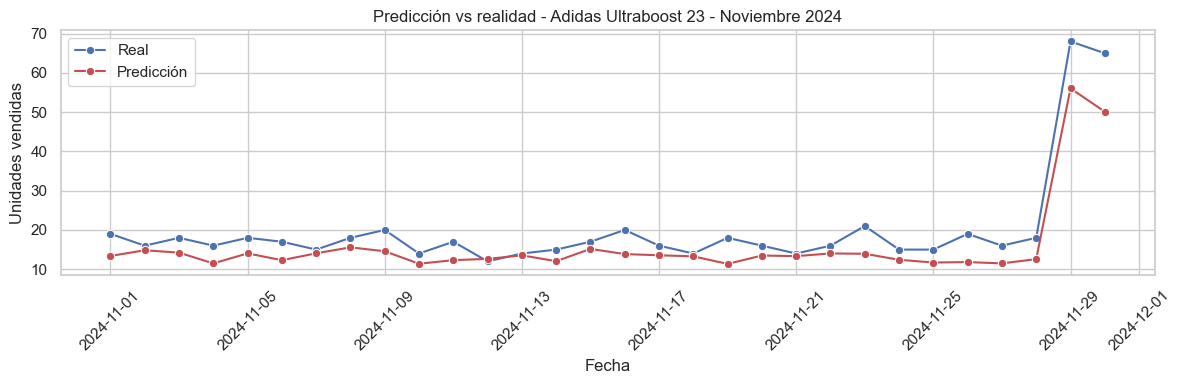

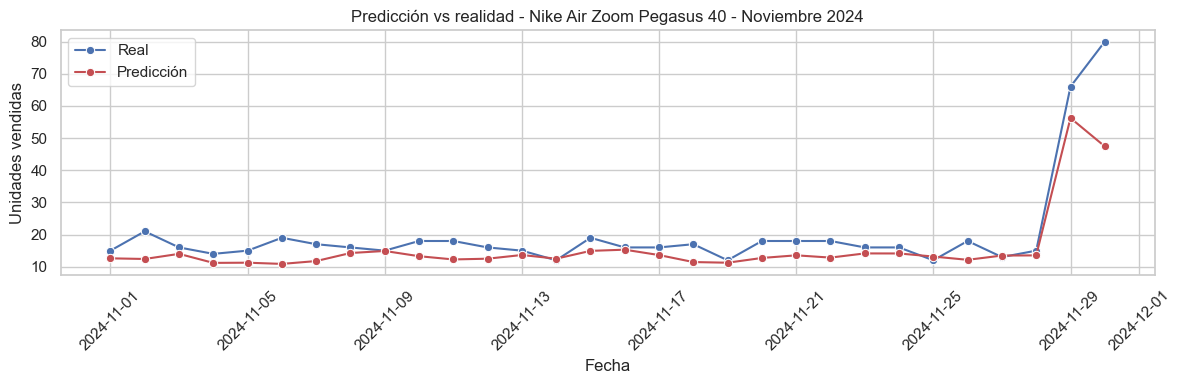

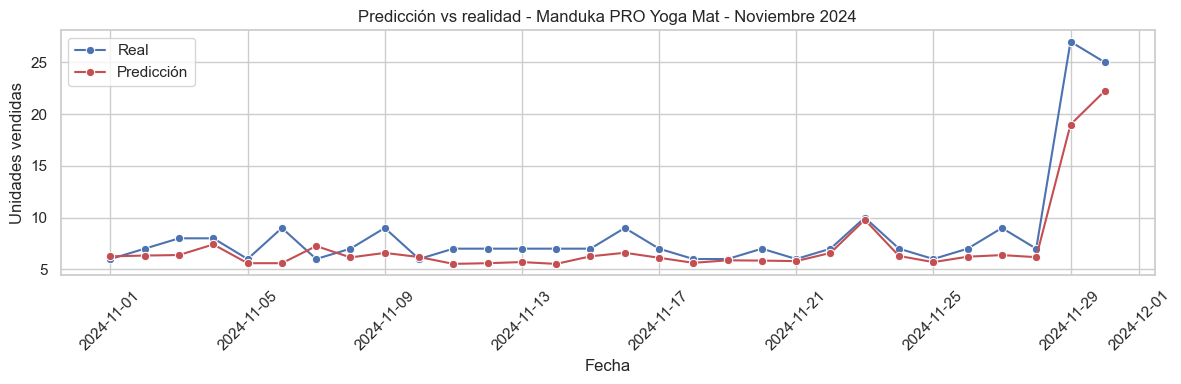

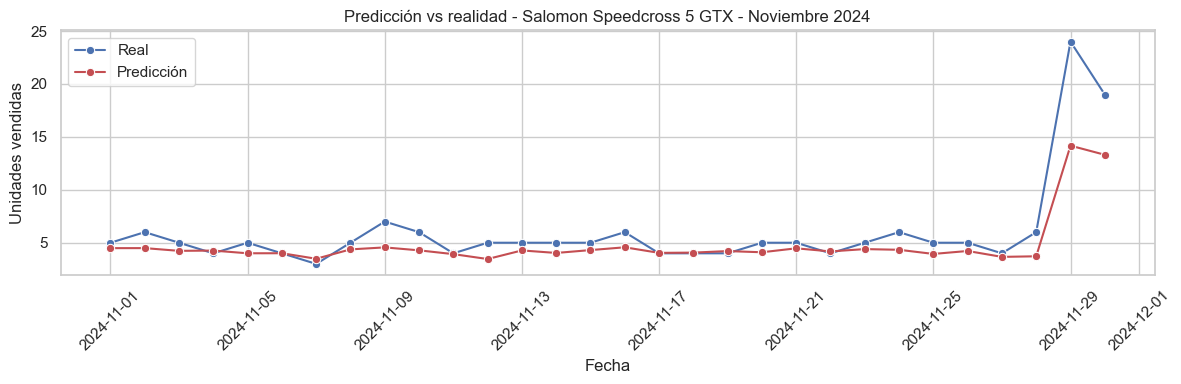

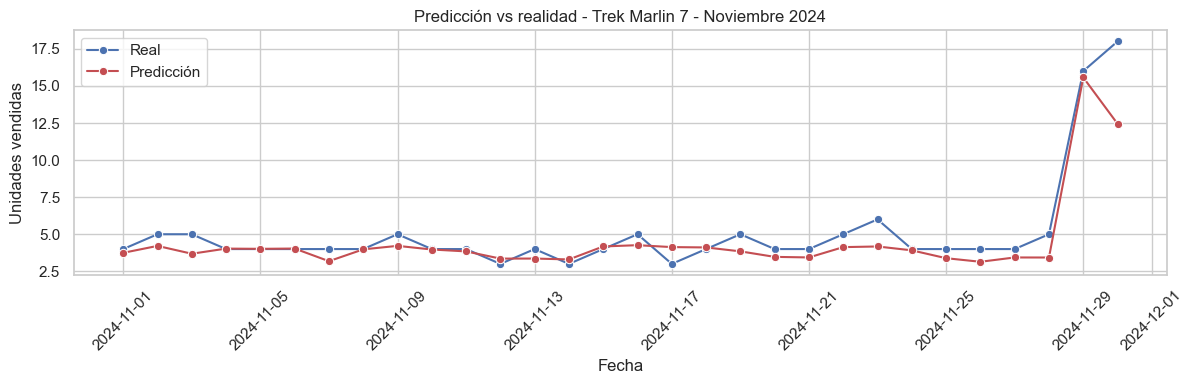

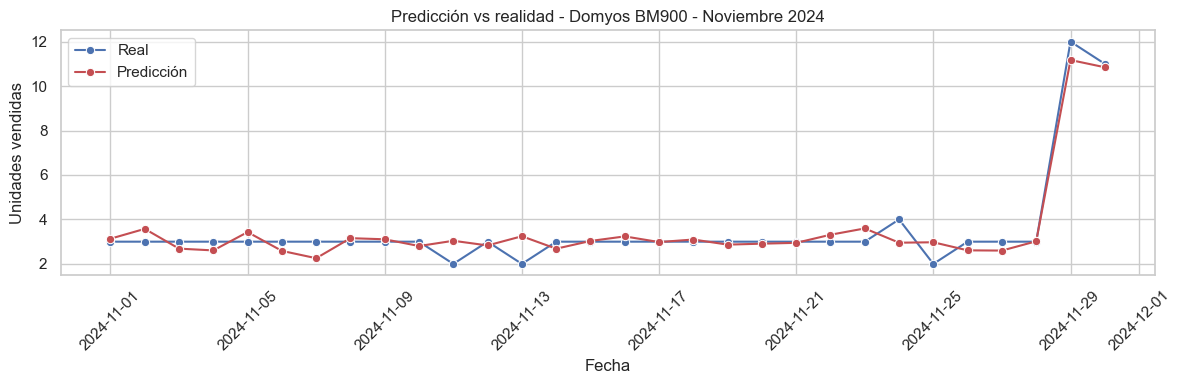

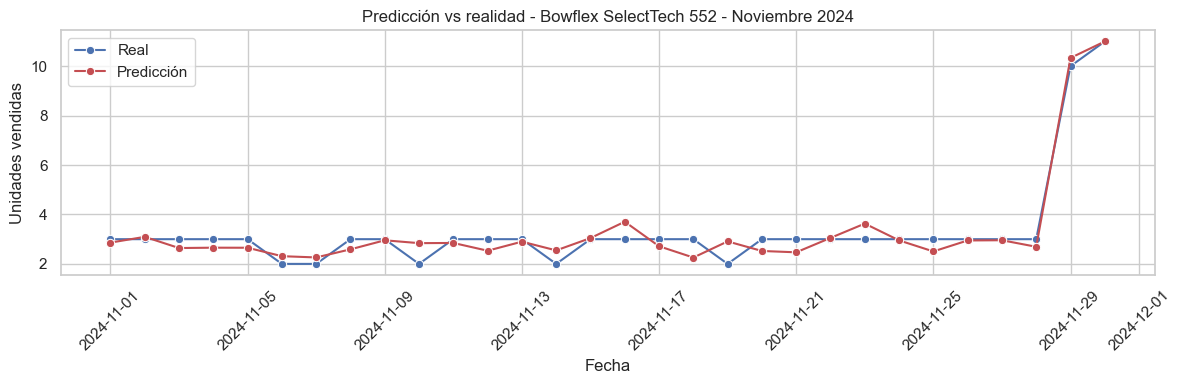

In [70]:
# Predicciones para noviembre de 2024 en los 7 productos estrella
nov_2024 = df[(df["anio"] == 2024) & (df["mes"] == 11)].copy()

if nov_2024.empty:
    raise ValueError("No se encontraron registros para noviembre de 2024 en el dataframe.")

if "es_estrella" not in nov_2024.columns:
    raise ValueError("La columna 'es_estrella' no existe en el dataframe.")

productos_estrella = (
    nov_2024[nov_2024["es_estrella"] == 1]
    .groupby("nombre")["unidades_vendidas"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
    .tolist()
)

if len(productos_estrella) == 0:
    raise ValueError("No se encontraron productos estrella en noviembre de 2024.")

print("Productos estrella seleccionados para predicción:")
for producto in productos_estrella:
    print("-", producto)

for producto in productos_estrella:
    producto_df = nov_2024[nov_2024["nombre"] == producto].sort_values("fecha").reset_index(drop=True)
    if producto_df.empty:
        continue

    X_pred = producto_df[X_cols]
    y_true = producto_df["unidades_vendidas"]
    y_pred = model.predict(X_pred)
    producto_df["prediccion_unidades"] = y_pred

    plt.figure(figsize=(12, 4))
    sns.lineplot(data=producto_df, x="fecha", y="unidades_vendidas", marker="o", label="Real", color="#4C72B0")
    sns.lineplot(data=producto_df, x="fecha", y="prediccion_unidades", marker="o", label="Predicción", color="#C44E52")
    plt.title(f"Predicción vs realidad - {producto} - Noviembre 2024")
    plt.xlabel("Fecha")
    plt.ylabel("Unidades vendidas")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [71]:
# Cálculo del MAE por producto estrella para noviembre de 2024
nov_2024 = df[(df["anio"] == 2024) & (df["mes"] == 11)].copy()

if nov_2024.empty:
    raise ValueError("No se encontraron registros para noviembre de 2024 en el dataframe.")

if "es_estrella" not in nov_2024.columns:
    raise ValueError("La columna 'es_estrella' no existe en el dataframe.")

productos_estrella = (
    nov_2024[nov_2024["es_estrella"] == 1]
    .groupby("nombre")["unidades_vendidas"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
    .tolist()
)

mae_resultados = []
for producto in productos_estrella:
    producto_df = nov_2024[nov_2024["nombre"] == producto].sort_values("fecha").reset_index(drop=True)
    if producto_df.empty:
        continue

    X_pred = producto_df[X_cols]
    y_true = producto_df["unidades_vendidas"]
    y_pred = model.predict(X_pred)
    mae_producto = mean_absolute_error(y_true, y_pred)

    mae_resultados.append({
        "nombre": producto,
        "mae": mae_producto,
        "observaciones": len(producto_df)
    })

mae_por_producto = pd.DataFrame(mae_resultados).sort_values("mae")
print("MAE por producto estrella (Noviembre 2024):")
print(mae_por_producto.to_string(index=False))

MAE por producto estrella (Noviembre 2024):
                  nombre      mae  observaciones
  Bowflex SelectTech 552 0.335896             30
            Domyos BM900 0.387122             30
           Trek Marlin 7 0.743747             30
Salomon Speedcross 5 GTX 1.297662             30
    Manduka PRO Yoga Mat 1.325488             30
    Adidas Ultraboost 23 4.124636             30
Nike Air Zoom Pegasus 40 4.465474             30


Métricas de error por periodo para productos estrella en noviembre de 2024
periodo_noviembre      mae      rmse      mape  observaciones                   nombre
             1-10 3.515950  3.854197 20.133473             10     Adidas Ultraboost 23
            11-20 2.903749  3.596227 17.041337             10     Adidas Ultraboost 23
            21-30 5.954209  7.330518 22.662103             10     Adidas Ultraboost 23
             1-10 0.315108  0.378984 12.858385             10   Bowflex SelectTech 552
            11-20 0.443335  0.523472 17.204328             10   Bowflex SelectTech 552
            21-30 0.249245  0.337663  7.531255             10   Bowflex SelectTech 552
             1-10 0.346541  0.398470 11.551382             10             Domyos BM900
            11-20 0.337753  0.534153 15.066821             10             Domyos BM900
            21-30 0.477070  0.593342 14.206917             10             Domyos BM900
             1-10 1.163598  1.527428 14.885674         

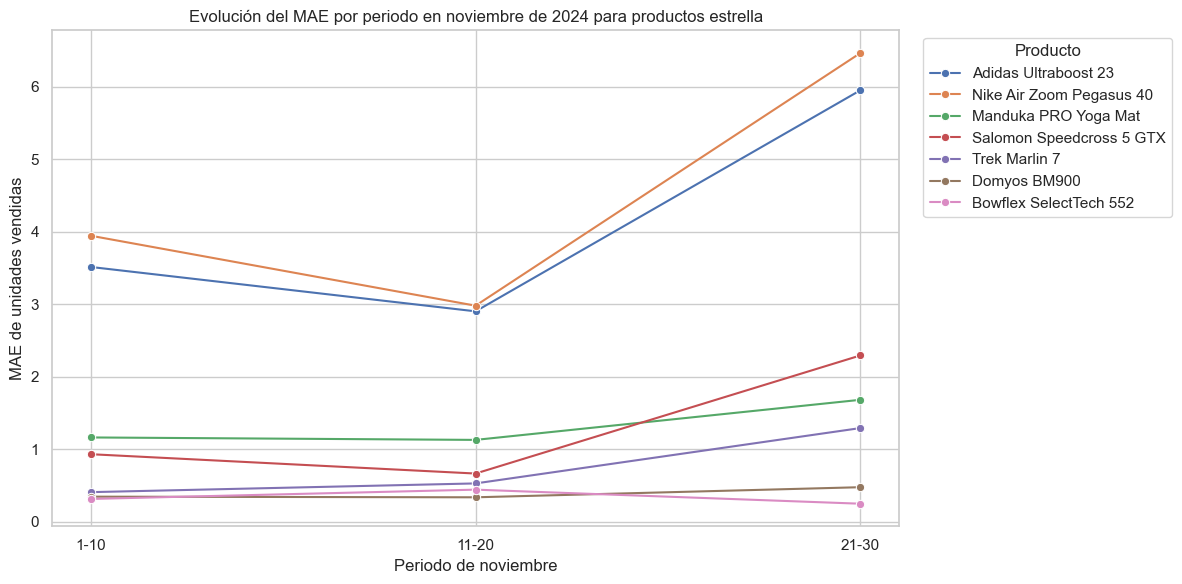

In [72]:
# Análisis de degradación de error a lo largo de noviembre de 2024
nov_2024 = df[(df["anio"] == 2024) & (df["mes"] == 11)].copy()

if nov_2024.empty:
    raise ValueError("No se encontraron registros para noviembre de 2024 en el dataframe.")

if "es_estrella" not in nov_2024.columns:
    raise ValueError("La columna 'es_estrella' no existe en el dataframe.")

productos_estrella = (
    nov_2024[nov_2024["es_estrella"] == 1]
    .groupby("nombre")["unidades_vendidas"]
    .sum()
    .sort_values(ascending=False)
    .head(7)
    .index
    .tolist()
)

nov_2024["periodo_noviembre"] = pd.cut(
    nov_2024["dia_mes"],
    bins=[0, 10, 20, 30],
    labels=["1-10", "11-20", "21-30"],
    right=True,
)

metricas_periodo = []
for producto in productos_estrella:
    producto_df = nov_2024[nov_2024["nombre"] == producto].sort_values("fecha").reset_index(drop=True)
    if producto_df.empty:
        continue

    X_pred = producto_df[X_cols]
    producto_df["prediccion_unidades"] = model.predict(X_pred)
    producto_df["abs_error"] = (producto_df["unidades_vendidas"] - producto_df["prediccion_unidades"]).abs()
    producto_df["mape"] = np.abs(
        (producto_df["unidades_vendidas"] - producto_df["prediccion_unidades"]) /
        producto_df["unidades_vendidas"].replace(0, np.nan)
    ) * 100

    resumen = (
        producto_df
        .groupby("periodo_noviembre")
        .agg(
            mae=("abs_error", "mean"),
            rmse=("abs_error", lambda x: np.sqrt(np.mean(x ** 2))),
            mape=("mape", "mean"),
            observaciones=("unidades_vendidas", "size"),
        )
        .reset_index()
    )
    resumen["nombre"] = producto
    metricas_periodo.append(resumen)

metricas_periodo = pd.concat(metricas_periodo, ignore_index=True)
metricas_periodo["periodo_noviembre"] = pd.Categorical(
    metricas_periodo["periodo_noviembre"],
    categories=["1-10", "11-20", "21-30"],
    ordered=True,
)

print("Métricas de error por periodo para productos estrella en noviembre de 2024")
print(metricas_periodo.sort_values(["nombre", "periodo_noviembre"]).to_string(index=False))

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=metricas_periodo,
    x="periodo_noviembre",
    y="mae",
    hue="nombre",
    marker="o",
)
plt.title("Evolución del MAE por periodo en noviembre de 2024 para productos estrella")
plt.xlabel("Periodo de noviembre")
plt.ylabel("MAE de unidades vendidas")
plt.legend(title="Producto", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

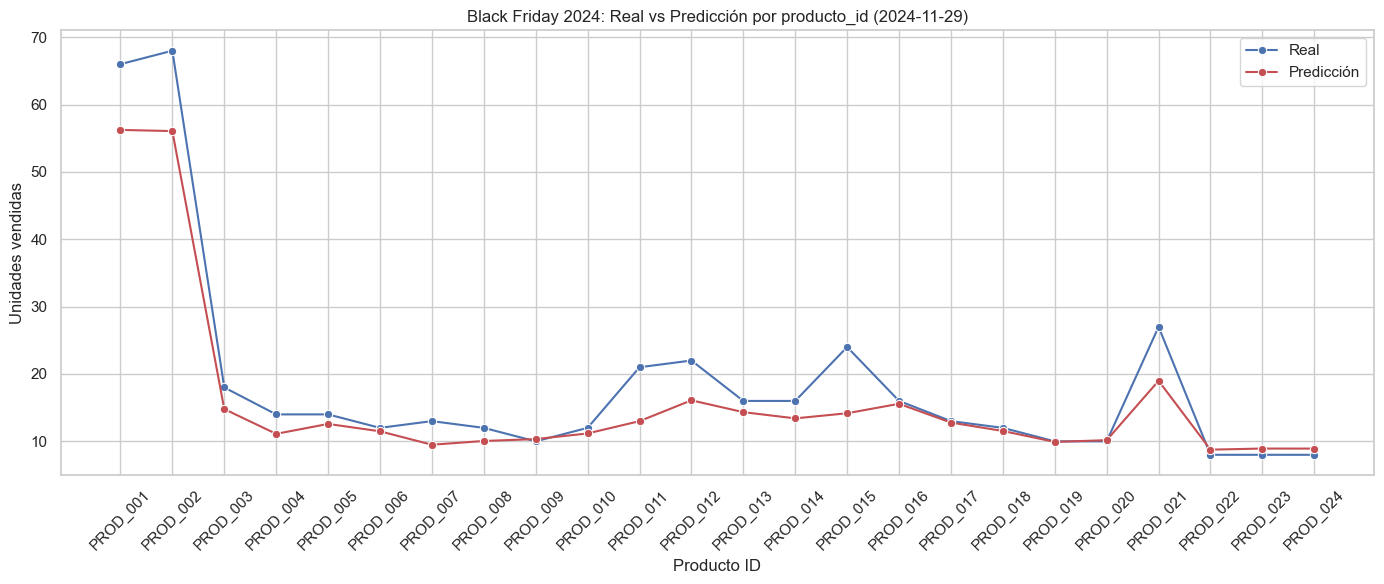

In [73]:
# Análisis de Black Friday 2024 para todos los productos: real vs predicho
bf_2024_date = pd.Timestamp(2024, 11, 1) + pd.offsets.WeekOfMonth(week=3, weekday=3) + pd.Timedelta(days=1)

bf_2024 = df[df["fecha"] == bf_2024_date].copy()
if bf_2024.empty:
    raise ValueError(f"No se encontraron registros para Black Friday 2024 ({bf_2024_date.date()}) en el dataframe.")

if not set(["producto_id", "unidades_vendidas"]).issubset(bf_2024.columns):
    raise ValueError("Faltan columnas necesarias para el análisis de Black Friday 2024.")

X_bf = bf_2024[X_cols]
bf_2024["prediccion_unidades"] = model.predict(X_bf)

bf_2024 = bf_2024.sort_values("producto_id").reset_index(drop=True)

plt.figure(figsize=(14, 6))
sns.lineplot(data=bf_2024, x="producto_id", y="unidades_vendidas", marker="o", label="Real", color="#4C72B0")
sns.lineplot(data=bf_2024, x="producto_id", y="prediccion_unidades", marker="o", label="Predicción", color="#C44E52")
plt.title(f"Black Friday 2024: Real vs Predicción por producto_id ({bf_2024_date.date()})")
plt.xlabel("Producto ID")
plt.ylabel("Unidades vendidas")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
# Reentrenar el modelo final con todo el histórico disponible de 2021 a 2024
full_train_df = df[df["anio"].isin([2021, 2022, 2023, 2024])].reset_index(drop=True)

if full_train_df.empty:
    raise ValueError("No hay datos históricos de 2021-2024 disponibles para reentrenar el modelo.")

X_full = full_train_df[X_cols]
y_full = full_train_df["unidades_vendidas"]

final_model = HistGradientBoostingRegressor(
    learning_rate=0.03,
    max_iter=500,
    max_depth=6,
    min_samples_leaf=20,
    max_leaf_nodes=31,
    l2_regularization=0.1,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=30,
)

final_model.fit(X_full, y_full)

print("Modelo final reentrenado con todo el histórico 2021-2024")
print("Registros usados para entrenamiento:", len(full_train_df))

Modelo final reentrenado con todo el histórico 2021-2024
Registros usados para entrenamiento: 3524


C:\Users\diego\AppData\Local\Temp\ipykernel_25776\404934493.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


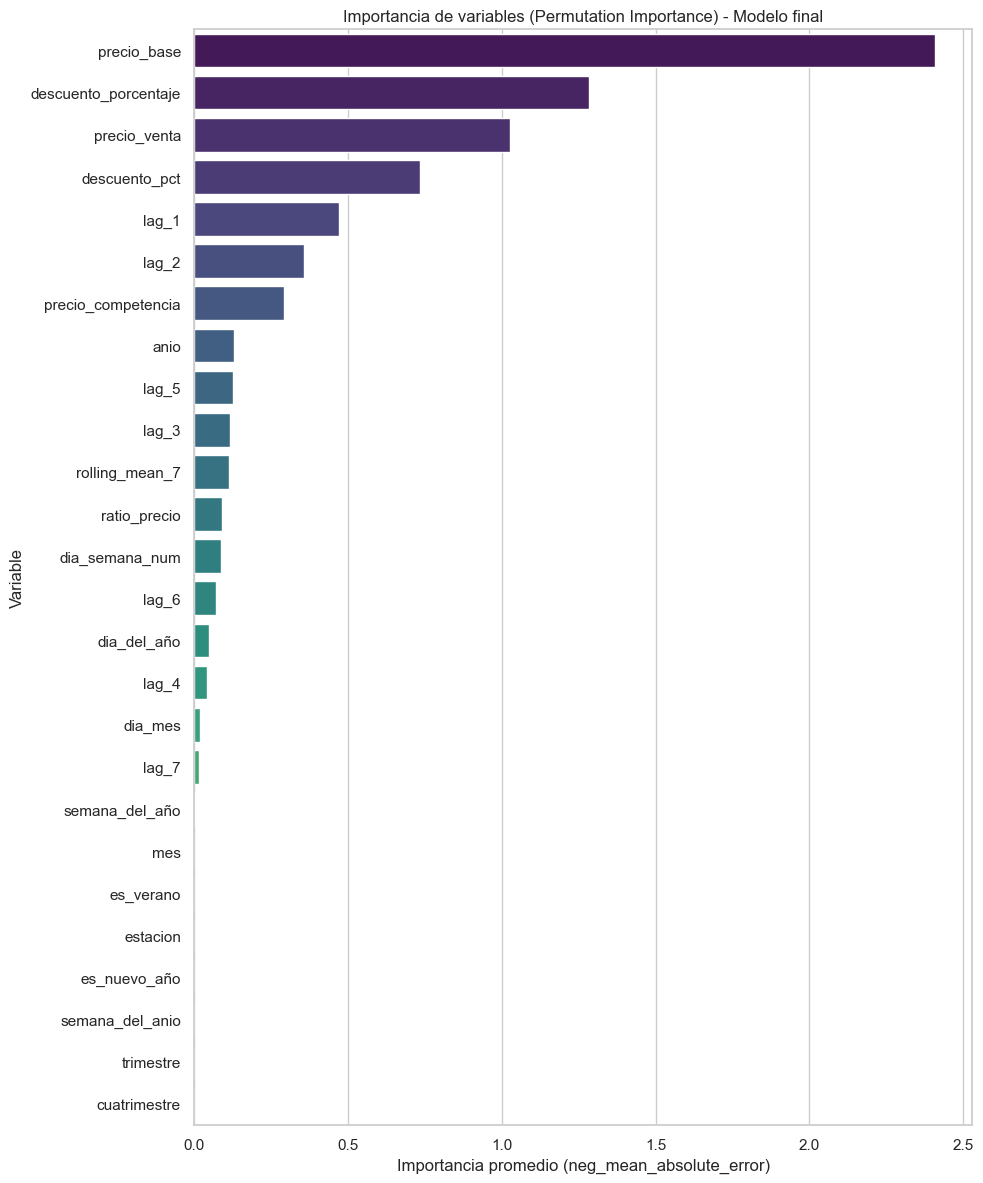

In [ ]:
# Importancia de variables con permutation importance usando el modelo final
from sklearn.inspection import permutation_importance
import joblib

result = permutation_importance(
    final_model,
    X_full,
    y_full,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": X_full.columns,
    "importance": result.importances_mean,
    "importance_std": result.importances_std,
})
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 12))
sns.barplot(
    data=importance_df,
    x="importance",
    y="feature",
    palette="viridis",
)
plt.title("Importancia de variables (Permutation Importance) - Modelo final")
plt.xlabel("Importancia promedio (neg_mean_absolute_error)")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [76]:
# Guardar el modelo final
models_dir = Path("../models").resolve()
models_dir.mkdir(parents=True, exist_ok=True)
model_path = models_dir / "modelo_final.joblib"
joblib.dump(final_model, model_path)
print(f"Modelo guardado en: {model_path}")

Modelo guardado en: C:\Users\diego\OneDrive\Desktop\Data_Science\models\modelo_final.joblib
